In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install openml


In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 2.5 MB/s eta 0:00:00


In [ ]:
import openml
from openml.datasets import get_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import category_encoders as ce
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

ModuleNotFoundError: No module named 'openml'

In [ ]:
# dataset = get_dataset(188)
# X, y, categorical_indicator, attribute_names = dataset.get_data(
#       dataset_format="dataframe", target=dataset.default_target_attribute)

# print(y.value_counts())
# y = ce.OrdinalEncoder(cols=['Utility']).fit_transform(y)

# ### create df
# df = pd.concat([X, y], axis=1)


# categorical_features = list(X.columns[categorical_indicator])
# continuous_features = list(X.columns[np.array(~np.array(categorical_indicator))]) # Convert list to numpy array before applying ~
# target_variable = 'Utility'


# df[continuous_features] = df[continuous_features].apply(pd.to_numeric, errors='coerce')
# df[categorical_features] = df[categorical_features].astype(str)

# df = df.dropna(subset=continuous_features, ignore_index = True)


# for col in continuous_features:
#   df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# for feat in categorical_features:
#   plt.figure(figsize=(10,5))
#   plt.bar(df[feat].value_counts().index, df[feat].value_counts().values)
#   plt.title(feat + ', card: '+ str(df[feat].nunique()))
#   plt.show()

# how_many_cv = 50
# which_encoders_to_try = ['nocat','glmm','tar','ohe','ord']
# dictionary_results = {}

# from sklearn.metrics import roc_auc_score

# for rep in range(how_many_cv):
#   #split data in train - test cv
#   df_train = df.sample(frac=0.7)
#   df_test = df.drop(df_train.index)




#   for encoder in which_encoders_to_try:
#     if encoder == 'nocat':
#       X_train = df_train[continuous_features]
#       X_test = df_test[continuous_features]

#       if rep == 0:
#         dictionary_results['nocat'] = []

#     elif encoder == 'glmm':
#       # encoder using glmm encoder
#       encoder_glmm = ce.GLMMEncoder(cols=categorical_features)
#       X_train = encoder_glmm.fit_transform(df_train[categorical_features], df_train[target_variable])
#       X_test = encoder_glmm.transform(df_test[categorical_features])

#       if rep == 0:
#         dictionary_results['glmm'] = []

#     elif encoder == 'tar':
#       # encoder using target encoder
#       encoder_tar = ce.TargetEncoder(cols=categorical_features, smoothing = 0.01)
#       X_train = encoder_tar.fit_transform(df_train[categorical_features], df_train[target_variable])
#       X_test = encoder_tar.transform(df_test[categorical_features])

#       if rep == 0:
#         dictionary_results['tar'] = []

#     elif encoder == 'ohe':
#       # encoder using one hot encoder
#       encoder_ohe = ce.OneHotEncoder(cols=categorical_features)
#       X_train = encoder_ohe.fit_transform(df_train[categorical_features])
#       X_test = encoder_ohe.transform(df_test[categorical_features])

#       if rep == 0:
#         dictionary_results['ohe'] = []

#     elif encoder == 'ord':
#       # encoder using ordinal encoder
#       encoder_ord = ce.OrdinalEncoder(cols=categorical_features)
#       X_train = encoder_ord.fit_transform(df_train[categorical_features])
#       X_test = encoder_ord.transform(df_test[categorical_features])

#       if rep == 0:
#         dictionary_results['ord'] = []

#     if encoder != 'nocat':
#       X_train = pd.concat([X_train, df_train[continuous_features]], axis=1)
#       X_test = pd.concat([X_test, df_test[continuous_features]], axis=1)

#     # now apply a simple logistic for multiclass classification
#     model = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty = None, max_iter=5000)
#     model.fit(X_train, df_train[target_variable])
#     y_pred = model.predict(X_test)
#     y_pred_proba = model.predict_proba(X_test)

#     # check performance
#     accuracy = accuracy_score(df_test[target_variable], y_pred)
#     aunu = roc_auc_score(df_test[target_variable], y_pred_proba, multi_class='ovr', average='weighted')
#     # print(f"Accuracy for {encoder}: {accuracy}")
#     # print(f"Aunu (ROC AUC) for {encoder}: {aunu}")
#     # print(classification_report(df_test[target_variable], y_pred))

#     dictionary_results[encoder].append({'accuracy': accuracy, 'aunu': aunu})

#   print('Rep: '+str(rep + 1) + ' out of '+str(how_many_cv))

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd

# # Prepare data for box plots
# accuracy_data = []
# aunu_data = []
# encoder_labels = []

# for encoder, results_list in dictionary_results.items():
#     if results_list: # Check if the list is not empty
#         accuracies = [res['accuracy'] for res in results_list]
#         aunus = [res['aunu'] for res in results_list]
#         accuracy_data.append(accuracies)
#         aunu_data.append(aunus)
#         encoder_labels.append(encoder)

# # Plotting Accuracy
# plt.figure(figsize=(10, 6))
# plt.boxplot(accuracy_data, labels=encoder_labels)
# plt.title('Box Plot of Accuracy Scores by Encoder')
# plt.xlabel('Encoder Type')
# plt.ylabel('Accuracy')
# plt.grid(True)
# plt.show()

# # Plotting Aunu (ROC AUC)
# plt.figure(figsize=(10, 6))
# plt.boxplot(aunu_data, labels=encoder_labels)
# plt.title('Box Plot of Aunu (ROC AUC) Scores by Encoder')
# plt.xlabel('Encoder Type')
# plt.ylabel('Aunu (ROC AUC)')
# plt.grid(True)
# plt.show()

In [ ]:
# # Install scikit-posthocs if not already installed
# try:
#     import scikit_posthocs as sp
# except ImportError:
#     !pip install scikit-posthocs
#     import scikit_posthocs as sp

# import pandas as pd
# from scipy import stats

# how_many_cv = 50 # From the notebook state

# # Prepare dataframes for accuracy and aunu
# accuracy_data_for_stats = {encoder: [] for encoder in which_encoders_to_try}
# aunu_data_for_stats = {encoder: [] for encoder in which_encoders_to_try}

# for encoder in which_encoders_to_try:
#     for result_dict in dictionary_results[encoder]:
#         accuracy_data_for_stats[encoder].append(result_dict['accuracy'])
#         aunu_data_for_stats[encoder].append(result_dict['aunu'])

# accuracy_df = pd.DataFrame(accuracy_data_for_stats)
# aunu_df = pd.DataFrame(aunu_data_for_stats)

# print("--- Statistical Analysis of Accuracy ---")
# # Perform Friedman test for accuracy
# stat, p = stats.friedmanchisquare(*[accuracy_df[col] for col in accuracy_df.columns])
# print(f"Friedman test for Accuracy: Chi-squared = {stat:.3f}, p-value = {p:.3f}")

# if p < 0.05:
#     print("Significant differences found in Accuracy between encoders (p < 0.05).")
#     # Perform Nemenyi post-hoc test for accuracy
#     nemenyi_accuracy = sp.posthoc_nemenyi_friedman(accuracy_df.values)
#     nemenyi_accuracy.columns = accuracy_df.columns
#     nemenyi_accuracy.index = accuracy_df.columns
#     print("\nNemenyi Post-hoc test for Accuracy (p-values):\n", nemenyi_accuracy)
# elif p == 0:
#     print("Highly significant differences found in Accuracy between encoders (p = 0).")
#     nemenyi_accuracy = sp.posthoc_nemenyi_friedman(accuracy_df.values)
#     nemenyi_accuracy.columns = accuracy_df.columns
#     nemenyi_accuracy.index = accuracy_df.columns
#     print("\nNemenyi Post-hoc test for Accuracy (p-values):\n", nemenyi_accuracy)
# else:
#     print("No significant differences found in Accuracy between encoders (p >= 0.05).")

# print("\n--- Statistical Analysis of Aunu (ROC AUC) ---")
# # Perform Friedman test for Aunu
# stat, p = stats.friedmanchisquare(*[aunu_df[col] for col in aunu_df.columns])
# print(f"Friedman test for Aunu: Chi-squared = {stat:.3f}, p-value = {p:.3f}")

# if p < 0.05:
#     print("Significant differences found in Aunu between encoders (p < 0.05).")
#     # Perform Nemenyi post-hoc test for Aunu
#     nemenyi_aunu = sp.posthoc_nemenyi_friedman(aunu_df.values)
#     nemenyi_aunu.columns = aunu_df.columns
#     nemenyi_aunu.index = aunu_df.columns
#     print("\nNemenyi Post-hoc test for Aunu (p-values):\n", nemenyi_aunu)
# elif p == 0:
#     print("Highly significant differences found in Aunu between encoders (p = 0).")
#     nemenyi_aunu = sp.posthoc_nemenyi_friedman(aunu_df.values)
#     nemenyi_aunu.columns = aunu_df.columns
#     nemenyi_aunu.index = aunu_df.columns
#     print("\nNemenyi Post-hoc test for Aunu (p-values):\n", nemenyi_aunu)
# else:
#     print("No significant differences found in Aunu between encoders (p >= 0.05).")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
from openml.datasets import get_dataset

import category_encoders as ce

from sklearn.metrics import accuracy_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.models import Model


class MyLayer(Layer):
    def call(self, small_models_outputs, inputs):
        return tf.concat([*small_models_outputs.values(), inputs["rest"]], axis=-1)


class SmallNetwork(Layer):
    def __init__(self, units, activation="sigmoid", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = activation

    def build(self, input_shape):
        self.dense_layers = []
        for units in self.units:
            self.dense_layers.append(
                Dense(
                    units,
                    activation=self.activation,
                    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=45),
                )
            )

    def call(self, inputs):
        h = inputs
        for dense_layer in self.dense_layers:
            h = dense_layer(h)
        return h


def calculate_normalized_entropy(series):
    """Return Shannon entropy normalized to [0, 1] by observed cardinality."""
    probabilities = series.value_counts(normalize=True)
    cardinality = len(probabilities)

    if cardinality <= 1:
        return 0.0

    shannon_entropy = -np.sum(probabilities * np.log2(probabilities))
    return shannon_entropy / np.log2(cardinality)


def categorical_feature_summary(df_train, df_full, categorical_features):
    """Summarize categorical structure for one training repetition."""
    rows = []

    for feature in categorical_features:
        train_cardinality = df_train[feature].nunique()
        full_cardinality = df_full[feature].nunique()

        rows.append({
            "feature": feature,
            "normalized_entropy": calculate_normalized_entropy(df_train[feature]),
            "cardinality": train_cardinality,
            "proportion": (
                train_cardinality / full_cardinality
                if full_cardinality > 0 else np.nan
            )
        })

    return pd.DataFrame(rows)


def make_multiclass_scores(y_true, y_pred, y_pred_proba):
    accuracy = accuracy_score(y_true, y_pred)

    try:
        aunu = roc_auc_score(
            y_true,
            y_pred_proba,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        aunu = np.nan

    y_true_one_hot = tf.keras.utils.to_categorical(
        np.asarray(y_true, dtype=np.int32),
        num_classes=y_pred_proba.shape[1]
    )
    brier = np.mean(np.sum((y_pred_proba - y_true_one_hot) ** 2, axis=1))

    return accuracy, aunu, brier


def make_training_callbacks():
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=30,
        min_lr=1e-5,
        verbose=0
    )

    return [early_stopping, reduce_lr]


def fit_simple_nn(X_train, y_train, X_val, y_val, X_test, y_test, n_classes, epochs=300):
    inputs = Input(shape=(X_train.shape[1],))

    initializer = tf.keras.initializers.GlorotUniform(seed=45)
    outputs = Dense(
        n_classes,
        activation="softmax",
        kernel_initializer=initializer
    )(inputs)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train.astype(np.float32),
        y_train.values.astype(np.int32),
        validation_data=(
            X_val.astype(np.float32),
            y_val.values.astype(np.int32)
        ),
        epochs=epochs,
        batch_size=32,
        callbacks=make_training_callbacks(),
        verbose=0
    )

    y_pred_proba = model.predict(X_test.astype(np.float32), verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    return y_pred, y_pred_proba


def build_joechar_inputs(
    df_train,
    df_val,
    df_test,
    y_train,
    categorical_features,
    continuous_features,
    target_variable,
    n_classes
):
    X_train_base = df_train.drop(columns=[target_variable])
    X_val_base = df_val.drop(columns=[target_variable])
    X_test_base = df_test.drop(columns=[target_variable])

    X_train_mod = pd.DataFrame(index=df_train.index)
    X_val_mod = pd.DataFrame(index=df_val.index)
    X_test_mod = pd.DataFrame(index=df_test.index)

    joechar_feature_groups = {}

    # Used only as a fallback for unseen categories; these are not inputs.
    class_priors = (
        y_train.value_counts(normalize=True)
        .sort_index()
        .reindex(range(n_classes), fill_value=0)
    )

    for cat_col in categorical_features:

        cols_for_this_cat = []

        category_frequency = (
            df_train[cat_col].value_counts(dropna=False) / len(df_train)
        ).to_dict()

        for class_id in range(n_classes):

            cat_prob_col = f"{cat_col}_catprob_{class_id}"
            class_map = (
                df_train
                .groupby(cat_col)[target_variable]
                .apply(lambda s: np.mean(s == class_id))
                .to_dict()
            )

            X_train_mod[cat_prob_col] = X_train_base[cat_col].map(class_map)
            X_val_mod[cat_prob_col] = X_val_base[cat_col].map(class_map)
            X_test_mod[cat_prob_col] = X_test_base[cat_col].map(class_map)

            X_train_mod[cat_prob_col] = X_train_mod[cat_prob_col].fillna(
                class_priors.loc[class_id]
            )
            X_val_mod[cat_prob_col] = X_val_mod[cat_prob_col].fillna(
                class_priors.loc[class_id]
            )
            X_test_mod[cat_prob_col] = X_test_mod[cat_prob_col].fillna(
                class_priors.loc[class_id]
            )

            cols_for_this_cat.append(cat_prob_col)

        frequency_col = f"{cat_col}_frequency"
        X_train_mod[frequency_col] = X_train_base[cat_col].map(category_frequency).fillna(0.0)
        X_val_mod[frequency_col] = X_val_base[cat_col].map(category_frequency).fillna(0.0)
        X_test_mod[frequency_col] = X_test_base[cat_col].map(category_frequency).fillna(0.0)
        cols_for_this_cat.append(frequency_col)

        joechar_feature_groups[cat_col] = cols_for_this_cat

    for col in continuous_features:
        X_train_mod[col] = df_train[col]
        X_val_mod[col] = df_val[col]
        X_test_mod[col] = df_test[col]

    train_inputs = {
        cat_col: X_train_mod[joechar_feature_groups[cat_col]].values.astype(np.float32)
        for cat_col in categorical_features
    }

    val_inputs = {
        cat_col: X_val_mod[joechar_feature_groups[cat_col]].values.astype(np.float32)
        for cat_col in categorical_features
    }

    test_inputs = {
        cat_col: X_test_mod[joechar_feature_groups[cat_col]].values.astype(np.float32)
        for cat_col in categorical_features
    }

    train_inputs["rest"] = X_train_mod[continuous_features].values.astype(np.float32)
    val_inputs["rest"] = X_val_mod[continuous_features].values.astype(np.float32)
    test_inputs["rest"] = X_test_mod[continuous_features].values.astype(np.float32)

    input_dims = {
        cat_col: n_classes + 1
        for cat_col in categorical_features
    }

    return train_inputs, val_inputs, test_inputs, input_dims


def build_joeohe_inputs(
    df_train,
    df_val,
    df_test,
    categorical_features,
    continuous_features,
    target_variable
):
    train_inputs = {}
    val_inputs = {}
    test_inputs = {}
    input_dims = {}

    for cat_col in categorical_features:
        encoder = ce.OneHotEncoder(cols=[cat_col], handle_unknown="value", handle_missing="value")

        dummies_train = encoder.fit_transform(df_train[[cat_col]])
        dummies_val = encoder.transform(df_val[[cat_col]])
        dummies_test = encoder.transform(df_test[[cat_col]])

        train_inputs[cat_col] = dummies_train.values.astype(np.float32)
        val_inputs[cat_col] = dummies_val.values.astype(np.float32)
        test_inputs[cat_col] = dummies_test.values.astype(np.float32)

        input_dims[cat_col] = dummies_train.shape[1]

    train_inputs["rest"] = df_train[continuous_features].values.astype(np.float32)
    val_inputs["rest"] = df_val[continuous_features].values.astype(np.float32)
    test_inputs["rest"] = df_test[continuous_features].values.astype(np.float32)

    return train_inputs, val_inputs, test_inputs, input_dims

def fit_joe_model(
    train_inputs,
    val_inputs,
    test_inputs,
    y_train,
    y_val,
    y_test,
    categorical_features,
    continuous_features,
    input_dims,
    n_classes,
    small_units,
    small_activation,
    epochs=300
):
    inputs = {}
    small_models = {}

    for cat_col in categorical_features:
        inputs[cat_col] = Input(shape=(input_dims[cat_col],), name=cat_col)

        small_models[cat_col] = SmallNetwork(
            small_units,
            activation=small_activation
        )

    inputs["rest"] = Input(shape=(len(continuous_features),), name="rest")

    small_outputs = {
        cat_col: small_models[cat_col](inputs[cat_col])
        for cat_col in categorical_features
    }

    h = MyLayer()(small_outputs, inputs)

    initializer = tf.keras.initializers.GlorotUniform(seed=45)
    outputs = Dense(
        n_classes,
        activation="softmax",
        kernel_initializer=initializer
    )(h)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        train_inputs,
        y_train.values.astype(np.int32),
        validation_data=(val_inputs, y_val.values.astype(np.int32)),
        epochs=epochs,
        batch_size=32,
        callbacks=make_training_callbacks(),
        verbose=0
    )

    y_pred_proba = model.predict(test_inputs, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    return y_pred, y_pred_proba


dataset_id = 188
dataset = get_dataset(dataset_id)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

print(y.value_counts())

target_variable = "Utility"

y = y.to_frame(name=target_variable)

n_levels = y[target_variable].nunique()

target_encoder = ce.OrdinalEncoder(cols=[target_variable])
y = target_encoder.fit_transform(y)
y[target_variable] = y[target_variable] - y[target_variable].min()
y[target_variable] = y[target_variable].astype(int)

df = pd.concat([X, y], axis=1)

categorical_features = list(X.columns[categorical_indicator])
continuous_features = list(X.columns[np.array(~np.array(categorical_indicator))])

df[continuous_features] = df[continuous_features].apply(pd.to_numeric, errors="coerce")
df[categorical_features] = df[categorical_features].astype(str)

df = df.dropna(subset=continuous_features, ignore_index=True)

for col in continuous_features:
    denom = df[col].max() - df[col].min()

    if denom != 0:
        df[col] = (df[col] - df[col].min()) / denom
    else:
        df[col] = 0


how_many_cv = 20

which_encoders_to_try = [
    "nocat",
    "glmm",
    "tar",
    "ohe",
    "ord",
    "joechar",
    "joeohe",
    "joechar_linear_nlevels",
    "joeohe_linear_nlevels"
]

dictionary_results = {"summaries": []}

n_classes = df[target_variable].nunique()


for rep in range(how_many_cv):

    df_train = df.sample(frac=0.7)
    df_remaining = df.drop(df_train.index)
    df_val = df_remaining.sample(frac=0.5)
    df_test = df_remaining.drop(df_val.index)

    y_train = df_train[target_variable]
    y_val = df_val[target_variable]
    y_test = df_test[target_variable]

    summary_df = categorical_feature_summary(
        df_train=df_train,
        df_full=df,
        categorical_features=categorical_features
    )
    dictionary_results["summaries"].append(summary_df)

    joechar_train_inputs, joechar_val_inputs, joechar_test_inputs, joechar_input_dims = build_joechar_inputs(
        df_train=df_train,
        df_val=df_val,
        df_test=df_test,
        y_train=y_train,
        categorical_features=categorical_features,
        continuous_features=continuous_features,
        target_variable=target_variable,
        n_classes=n_classes
    )

    joeohe_train_inputs, joeohe_val_inputs, joeohe_test_inputs, joeohe_input_dims = build_joeohe_inputs(
        df_train=df_train,
        df_val=df_val,
        df_test=df_test,
        categorical_features=categorical_features,
        continuous_features=continuous_features,
        target_variable=target_variable
    )

    for encoder in which_encoders_to_try:

        if rep == 0:
            dictionary_results[encoder] = []

        if encoder == "nocat":

            X_train = df_train[continuous_features].copy()
            X_val = df_val[continuous_features].copy()
            X_test = df_test[continuous_features].copy()

            y_pred, y_pred_proba = fit_simple_nn(
                X_train.values,
                y_train,
                X_val.values,
                y_val,
                X_test.values,
                y_test,
                n_classes
            )

        elif encoder == "glmm":

            encoder_glmm = ce.GLMMEncoder(cols=categorical_features)

            X_train_cat = encoder_glmm.fit_transform(
                df_train[categorical_features],
                y_train
            )
            X_val_cat = encoder_glmm.transform(df_val[categorical_features])
            X_test_cat = encoder_glmm.transform(df_test[categorical_features])

            X_train = pd.concat([X_train_cat, df_train[continuous_features]], axis=1)
            X_val = pd.concat([X_val_cat, df_val[continuous_features]], axis=1)
            X_test = pd.concat([X_test_cat, df_test[continuous_features]], axis=1)

            y_pred, y_pred_proba = fit_simple_nn(
                X_train.values,
                y_train,
                X_val.values,
                y_val,
                X_test.values,
                y_test,
                n_classes
            )

        elif encoder == "tar":

            encoder_tar = ce.TargetEncoder(
                cols=categorical_features,
                smoothing=0.01
            )

            X_train_cat = encoder_tar.fit_transform(
                df_train[categorical_features],
                y_train
            )
            X_val_cat = encoder_tar.transform(df_val[categorical_features])
            X_test_cat = encoder_tar.transform(df_test[categorical_features])

            X_train = pd.concat([X_train_cat, df_train[continuous_features]], axis=1)
            X_val = pd.concat([X_val_cat, df_val[continuous_features]], axis=1)
            X_test = pd.concat([X_test_cat, df_test[continuous_features]], axis=1)

            y_pred, y_pred_proba = fit_simple_nn(
                X_train.values,
                y_train,
                X_val.values,
                y_val,
                X_test.values,
                y_test,
                n_classes
            )

        elif encoder == "ohe":

            encoder_ohe = ce.OneHotEncoder(cols=categorical_features)

            X_train_cat = encoder_ohe.fit_transform(df_train[categorical_features])
            X_val_cat = encoder_ohe.transform(df_val[categorical_features])
            X_test_cat = encoder_ohe.transform(df_test[categorical_features])

            X_train = pd.concat([X_train_cat, df_train[continuous_features]], axis=1)
            X_val = pd.concat([X_val_cat, df_val[continuous_features]], axis=1)
            X_test = pd.concat([X_test_cat, df_test[continuous_features]], axis=1)

            y_pred, y_pred_proba = fit_simple_nn(
                X_train.values,
                y_train,
                X_val.values,
                y_val,
                X_test.values,
                y_test,
                n_classes
            )

        elif encoder == "ord":

            encoder_ord = ce.OrdinalEncoder(cols=categorical_features)

            X_train_cat = encoder_ord.fit_transform(df_train[categorical_features])
            X_val_cat = encoder_ord.transform(df_val[categorical_features])
            X_test_cat = encoder_ord.transform(df_test[categorical_features])

            X_train = pd.concat([X_train_cat, df_train[continuous_features]], axis=1)
            X_val = pd.concat([X_val_cat, df_val[continuous_features]], axis=1)
            X_test = pd.concat([X_test_cat, df_test[continuous_features]], axis=1)

            y_pred, y_pred_proba = fit_simple_nn(
                X_train.values,
                y_train,
                X_val.values,
                y_val,
                X_test.values,
                y_test,
                n_classes
            )

        elif encoder == "joechar":

            y_pred, y_pred_proba = fit_joe_model(
                train_inputs=joechar_train_inputs,
                val_inputs=joechar_val_inputs,
                test_inputs=joechar_test_inputs,
                y_train=y_train,
                y_val=y_val,
                y_test=y_test,
                categorical_features=categorical_features,
                continuous_features=continuous_features,
                input_dims=joechar_input_dims,
                n_classes=n_classes,
                small_units=[8, n_levels],
                small_activation="sigmoid"
            )

        elif encoder == "joechar_linear_nlevels":

            y_pred, y_pred_proba = fit_joe_model(
                train_inputs=joechar_train_inputs,
                val_inputs=joechar_val_inputs,
                test_inputs=joechar_test_inputs,
                y_train=y_train,
                y_val=y_val,
                y_test=y_test,
                categorical_features=categorical_features,
                continuous_features=continuous_features,
                input_dims=joechar_input_dims,
                n_classes=n_classes,
                small_units=[n_levels],
                small_activation="linear"
            )

        elif encoder == "joeohe":

            y_pred, y_pred_proba = fit_joe_model(
                train_inputs=joeohe_train_inputs,
                val_inputs=joeohe_val_inputs,
                test_inputs=joeohe_test_inputs,
                y_train=y_train,
                y_val=y_val,
                y_test=y_test,
                categorical_features=categorical_features,
                continuous_features=continuous_features,
                input_dims=joeohe_input_dims,
                n_classes=n_classes,
                small_units=[8, n_levels],
                small_activation="sigmoid"
            )

        elif encoder == "joeohe_linear_nlevels":

            y_pred, y_pred_proba = fit_joe_model(
                train_inputs=joeohe_train_inputs,
                val_inputs=joeohe_val_inputs,
                test_inputs=joeohe_test_inputs,
                y_train=y_train,
                y_val=y_val,
                y_test=y_test,
                categorical_features=categorical_features,
                continuous_features=continuous_features,
                input_dims=joeohe_input_dims,
                n_classes=n_classes,
                small_units=[n_levels],
                small_activation="linear"
            )

        accuracy, aunu, brier = make_multiclass_scores(
            y_test,
            y_pred,
            y_pred_proba
        )

        dictionary_results[encoder].append({
            "accuracy": accuracy,
            "aunu": aunu,
            "brier": brier
        })

    print("Rep: " + str(rep + 1) + " out of " + str(how_many_cv))


print(dictionary_results)


Utility
good       214
none       180
average    130
low        107
best       105
Name: count, dtype: int64


Rep: 1 out of 20
Rep: 2 out of 20
Rep: 3 out of 20
Rep: 4 out of 20
Rep: 5 out of 20
Rep: 6 out of 20
Rep: 7 out of 20
Rep: 8 out of 20
Rep: 9 out of 20
Rep: 10 out of 20
Rep: 11 out of 20
Rep: 12 out of 20
Rep: 13 out of 20
Rep: 14 out of 20
Rep: 15 out of 20
Rep: 16 out of 20
Rep: 17 out of 20
Rep: 18 out of 20
Rep: 19 out of 20
Rep: 20 out of 20
{'summaries': [    feature  normalized_entropy  cardinality  proportion
0    Abbrev            0.953914           13         1.0
1  Locality            0.892211            6         1.0
2   Map_Ref            0.914064           11         1.0
3  Latitude            0.916256            9         1.0
4        Sp            0.889949           25         1.0,     feature  normalized_entropy  cardinality  proportion
0    Abbrev            0.948146           13         1.0
1  Locality            0.870467            6         1.0
2   Map_Ref            0.909313           11         1.0
3  Latitude            0.904110            9         1.0
4     

In [ ]:
import pickle

output_path = (
    f"/content/drive/MyDrive/multi_class/"
    f"multiclass_results_dataset_{dataset_id}.pkl"
)

with open(output_path, "wb") as file:
    pickle.dump(dictionary_results, file)

print(f"Results saved to: {output_path}")

Results saved to: /content/drive/MyDrive/multi_class/multiclass_results_dataset_188.pkl


In [ ]:
import pickle
file_path = (
    f"/content/drive/MyDrive/multi_class/"
    f"multiclass_results_dataset_188.pkl"
)

# 1. Load the dictionary from the pickle file
with open(file_path, "rb") as file:
    dictionary_results = pickle.load(file)

In [ ]:
dictionary_results

{'summaries': [    feature  normalized_entropy  cardinality  proportion
  0    Abbrev            0.953914           13         1.0
  1  Locality            0.892211            6         1.0
  2   Map_Ref            0.914064           11         1.0
  3  Latitude            0.916256            9         1.0
  4        Sp            0.889949           25         1.0,
      feature  normalized_entropy  cardinality  proportion
  0    Abbrev            0.948146           13         1.0
  1  Locality            0.870467            6         1.0
  2   Map_Ref            0.909313           11         1.0
  3  Latitude            0.904110            9         1.0
  4        Sp            0.888701           25         1.0,
      feature  normalized_entropy  cardinality  proportion
  0    Abbrev            0.950723           13         1.0
  1  Locality            0.888879            6         1.0
  2   Map_Ref            0.920425           11         1.0
  3  Latitude            0.928280        

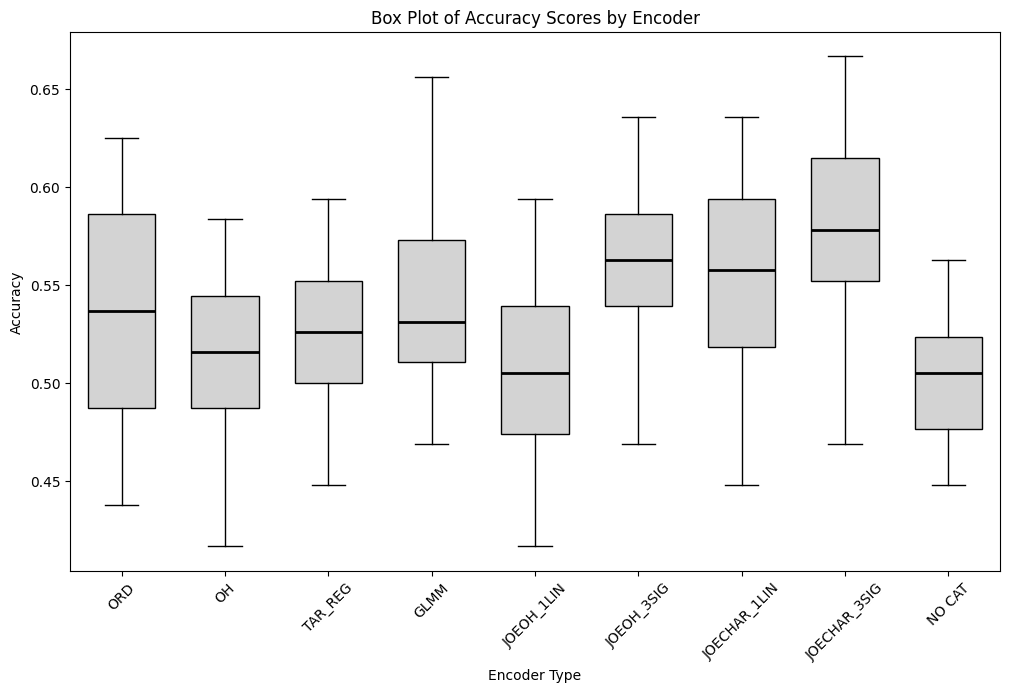

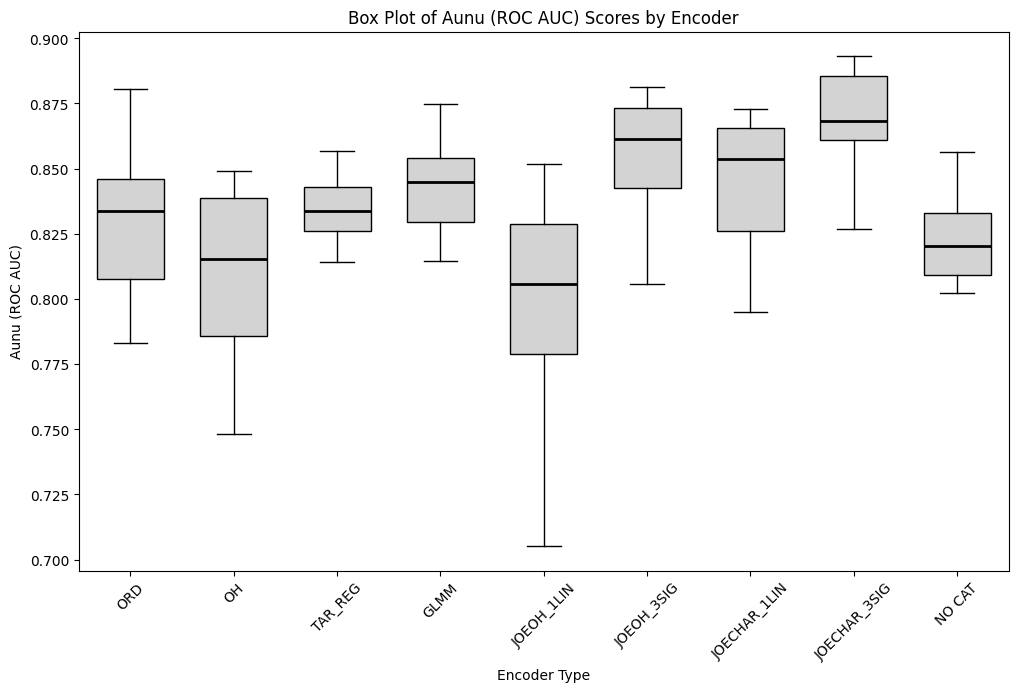

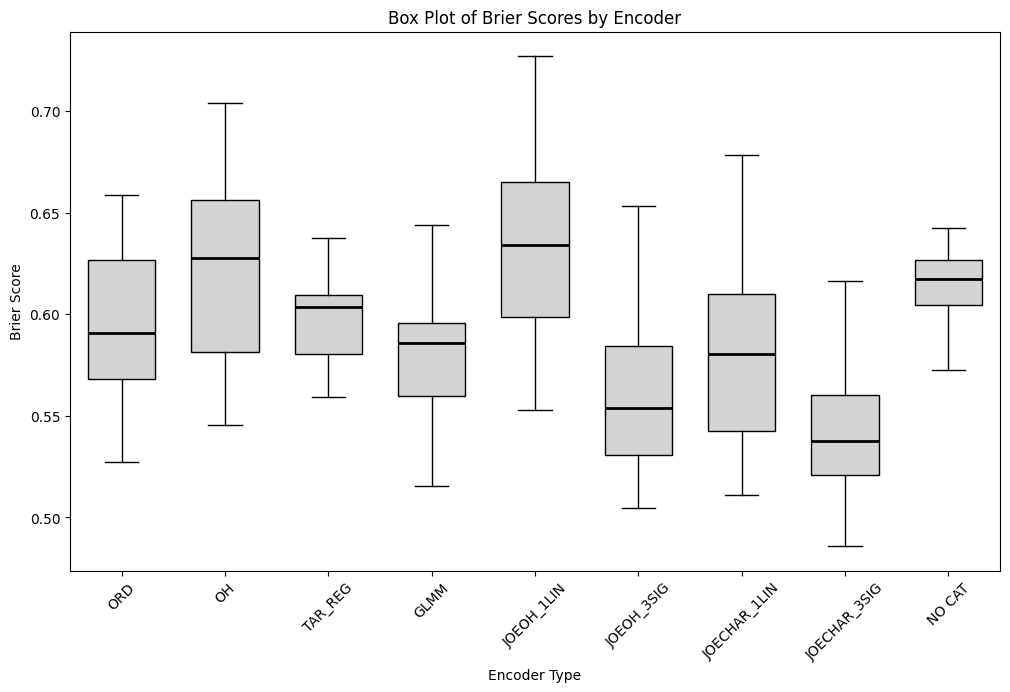

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for box plots for all encoders including 'joechar' and 'joeohe'
accuracy_data = []
aunu_data = []
brier_data = [] # New list for brier scores
encoder_labels = []

# Define the new encoder names as requested by the user
methods_list = [
    'ORD',
    'OH',
    'TAR_REG',
    'GLMM',
    'JOEOH_1LIN', # Changed 'ENT' to 'JOEOH_1LIN' based on the notebook's internal mapping
    'JOEOH_3SIG',
    'JOECHAR_1LIN',
    'JOECHAR_3SIG',
    'NO CAT'
]

# Correct mapping based on the implicit order of the user's requested `methods_list` and the notebook's `which_encoders_to_try`:
# The order in the methods_list provided by the user does not directly map to the `which_encoders_to_try` variable's order.
# I will re-create `accuracy_data`, `aunu_data`, `brier_data` based on a corrected `ordered_which_encoders` to match the `methods_list`.

# Based on the user's methods_list and the `which_encoders_to_try` from the notebook's state, here's a plausible mapping:
ordered_which_encoders = [
    'ord',                    # corresponds to 'ORD'
    'ohe',                    # corresponds to 'OH'
    'tar',                    # corresponds to 'TAR_REG'
    'glmm',                   # corresponds to 'GLMM'
    'joeohe_linear_nlevels',  # corresponds to 'JOEOH_1LIN' (assuming 'ENT' meant linear JOEOH)
    'joeohe',                 # corresponds to 'JOEOH_3SIG'
    'joechar_linear_nlevels', # corresponds to 'JOECHAR_1LIN'
    'joechar',                # corresponds to 'JOECHAR_3SIG'
    'nocat'                   # corresponds to 'NO CAT'
]

for encoder_key in ordered_which_encoders:
    results_list = dictionary_results.get(encoder_key, [])
    if results_list:  # Check if the list is not empty
        accuracies = [res['accuracy'] for res in results_list]
        aunus = [res['aunu'] for res in results_list]
        briers = [res['brier'] for res in results_list]
        accuracy_data.append(accuracies)
        aunu_data.append(aunus)
        brier_data.append(briers)

# Now, assign the user-provided methods_list as encoder_labels directly
encoder_labels = methods_list

# Plotting Accuracy
plt.figure(figsize=(12, 7))
bp_acc = plt.boxplot(accuracy_data, tick_labels=encoder_labels, patch_artist=True, showmeans=False, showfliers=False, widths=0.65)
for box in bp_acc['boxes']:
    box.set(facecolor='lightgrey', edgecolor='black', alpha=1.0)
for whisker in bp_acc['whiskers']:
    whisker.set(color='black')
for cap in bp_acc['caps']:
    cap.set(color='black')
for median in bp_acc['medians']:
    median.set(color='black', linewidth=2)
for flier in bp_acc['fliers']:
    flier.set(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=4)
plt.title('Box Plot of Accuracy Scores by Encoder')
plt.xlabel('Encoder Type')
plt.ylabel('Accuracy')
plt.grid(False)
plt.xticks(rotation=45)
plt.show()

# Plotting Aunu (ROC AUC)
plt.figure(figsize=(12, 7))
bp_aunu = plt.boxplot(aunu_data, tick_labels=encoder_labels, patch_artist=True, showmeans=False, showfliers=False, widths=0.65)
for box in bp_aunu['boxes']:
    box.set(facecolor='lightgrey', edgecolor='black', alpha=1.0)
for whisker in bp_aunu['whiskers']:
    whisker.set(color='black')
for cap in bp_aunu['caps']:
    cap.set(color='black')
for median in bp_aunu['medians']:
    median.set(color='black', linewidth=2)
for flier in bp_aunu['fliers']:
    flier.set(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=4)
plt.title('Box Plot of Aunu (ROC AUC) Scores by Encoder')
plt.xlabel('Encoder Type')
plt.ylabel('Aunu (ROC AUC)')
plt.grid(False)
plt.xticks(rotation=45)
plt.show()

# Plotting Brier Score
plt.figure(figsize=(12, 7))
bp_brier = plt.boxplot(brier_data, tick_labels=encoder_labels, patch_artist=True, showmeans=False, showfliers=False, widths=0.65)
for box in bp_brier['boxes']:
    box.set(facecolor='lightgrey', edgecolor='black', alpha=1.0)
for whisker in bp_brier['whiskers']:
    whisker.set(color='black')
for cap in bp_brier['caps']:
    cap.set(color='black')
for median in bp_brier['medians']:
    median.set(color='black', linewidth=2)
for flier in bp_brier['fliers']:
    flier.set(marker='o', markerfacecolor='none', markeredgecolor='black', markersize=4)
plt.title('Box Plot of Brier Scores by Encoder')
plt.xlabel('Encoder Type')
plt.ylabel('Brier Score')
plt.grid(False)
plt.xticks(rotation=45)
plt.show()

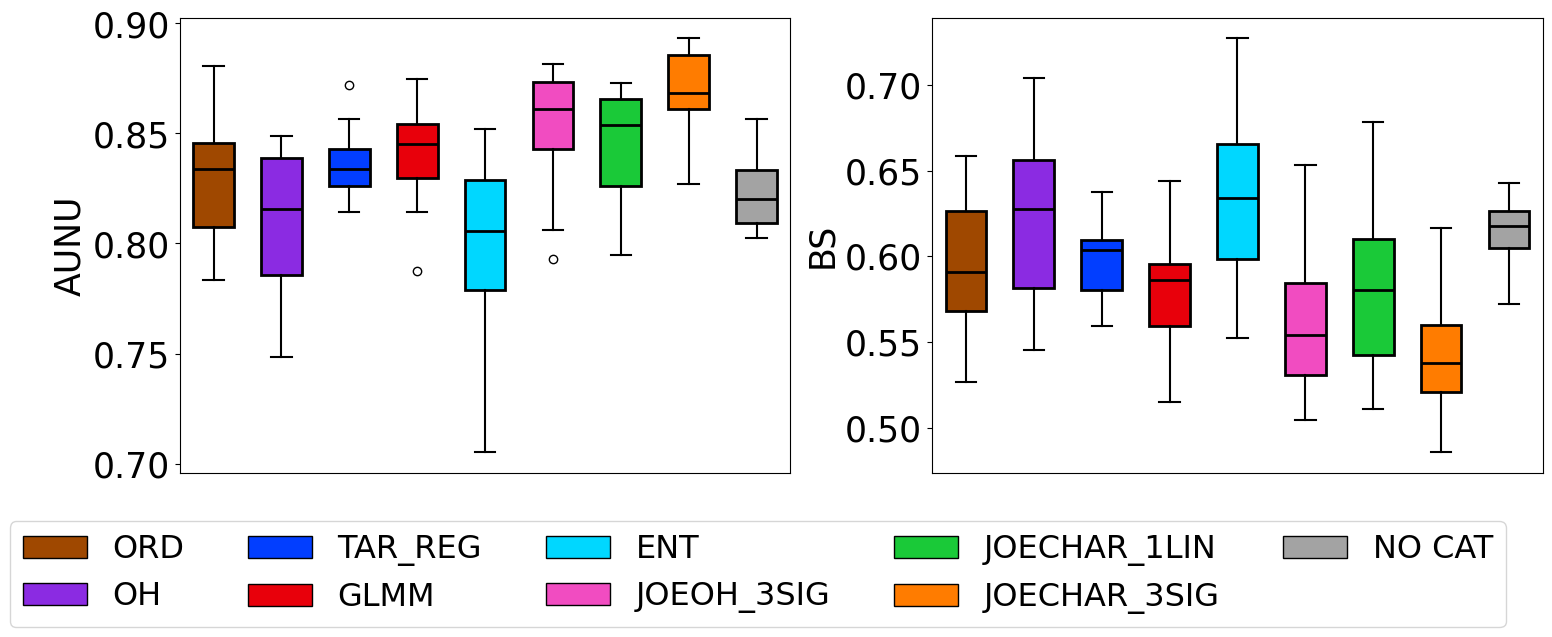

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# LOAD SAME COLOURS AS BINARY EXPERIMENTS
# ============================================================

with open("/content/drive/MyDrive/multi_class/method_colors.pkl", "rb") as f:
    method_colors = pickle.load(f)


# ============================================================
# MAP MULTICLASS ENCODER NAMES -> NAMES USED IN YOUR PAPER/PLOTS
# ============================================================

model_name_mapping = {
    "nocat": "NO CAT",
    "tar": "TAR_REG",
    "glmm": "GLMM",
    "ohe": "OH",
    "ord": "ORD",

    # JoeOHE
    "joeohe_linear_nlevels": "ENT",
    "joeohe": "JOEOH_3SIG",

    # JoeCHAR
    "joechar_linear_nlevels": "JOECHAR_1LIN",
    "joechar": "JOECHAR_3SIG",
}


# Same order as your binary plots
methods_list = [
    "ORD",
    "OH",
    "TAR_REG",
    "GLMM",
    "ENT",
    "JOEOH_3SIG",
    "JOECHAR_1LIN",
    "JOECHAR_3SIG",
    "NO CAT"
]


# ============================================================
# METRICS TO PLOT
# ============================================================

metric_names_to_plot = [
    ("aunu", "AUNU"),
    ("brier", "BS")
]


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    len(metric_names_to_plot),
    figsize=(16, 6),
    squeeze=False
)


# Reverse mapping:
# "ORD" -> "ord"
# "OH" -> "ohe"
# etc.
reverse_map = {
    pretty_name: original_name
    for original_name, pretty_name in model_name_mapping.items()
}


for col_index, (metric_key, metric_label) in enumerate(metric_names_to_plot):

    ax = axes[0, col_index]

    boxplot_data = []
    colors = []
    plotted_methods = []

    # --------------------------------------------------------
    # Collect methods IN THE SAME ORDER as binary plots
    # --------------------------------------------------------

    for pretty_name in methods_list:

        if pretty_name not in reverse_map:
            continue

        encoder = reverse_map[pretty_name]

        if encoder not in dictionary_results:
            continue

        values = [
            result[metric_key]
            for result in dictionary_results[encoder]
        ]

        # Remove NaNs, especially possible for AUC
        values = np.asarray(values, dtype=float)
        values = values[~np.isnan(values)]

        if len(values) == 0:
            continue

        boxplot_data.append(values)
        plotted_methods.append(pretty_name)

        # EXACT SAME colour dictionary as binary plot
        colors.append(
            method_colors.get(pretty_name, "red")
        )


    # --------------------------------------------------------
    # BOXPLOT
    # --------------------------------------------------------

    bp = ax.boxplot(
        boxplot_data,
        positions=np.arange(len(boxplot_data)),
        widths=0.6,
        patch_artist=True
    )


    # --------------------------------------------------------
    # APPLY METHOD COLOURS
    # --------------------------------------------------------

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_linewidth(2)

    for median in bp["medians"]:
        median.set(
            color="black",
            linewidth=2
        )

    for whisker in bp["whiskers"]:
        whisker.set(
            color="black",
            linewidth=1.5
        )

    for cap in bp["caps"]:
        cap.set(
            color="black",
            linewidth=1.5
        )


    # --------------------------------------------------------
    # AXIS STYLE — SAME IDEA AS BINARY FIGURE
    # --------------------------------------------------------

    ax.set_xticks([])

    ax.set_ylabel(
        metric_label,
        fontsize=25
    )

    ax.tick_params(
        axis="y",
        labelsize=25
    )


# ============================================================
# SHARED LEGEND
# ============================================================

legend_patches = []

for pretty_name in methods_list:

    # only put methods actually present in this experiment
    if pretty_name in reverse_map:

        encoder = reverse_map[pretty_name]

        if encoder in dictionary_results:

            legend_patches.append(
                Patch(
                    facecolor=method_colors.get(pretty_name, "red"),
                    edgecolor="black",
                    label=pretty_name
                )
            )


fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=23
)



# Reserve more space at the bottom for the legend
plt.tight_layout(
    rect=[0.05, 0.16, 1, 1]
)

plt.savefig(
    "/content/drive/MyDrive/multi_class/multiclass_real_results_188.pdf",
    bbox_inches="tight",
    pad_inches=0.3
)

plt.show()

In [ ]:
try:
    import scikit_posthocs as sp
except ImportError:
    !pip install scikit-posthocs
    import scikit_posthocs as sp

import pandas as pd
from scipy import stats

# Prepare dataframes for accuracy and aunu
accuracy_data_for_stats = {encoder: [] for encoder in which_encoders_to_try}
aunu_data_for_stats = {encoder: [] for encoder in which_encoders_to_try}

for encoder in which_encoders_to_try:
    if encoder in dictionary_results: # Ensure encoder exists in results
        for result_dict in dictionary_results[encoder]:
            accuracy_data_for_stats[encoder].append(result_dict['accuracy'])
            aunu_data_for_stats[encoder].append(result_dict['aunu'])

accuracy_df = pd.DataFrame(accuracy_data_for_stats)
aunu_df = pd.DataFrame(aunu_data_for_stats)

print("--- Statistical Analysis of Accuracy ---")
# Perform Friedman test for accuracy
stat, p = stats.friedmanchisquare(*[accuracy_df[col] for col in accuracy_df.columns])
print(f"Friedman test for Accuracy: Chi-squared = {stat:.3f}, p-value = {p:.3f}")

if p < 0.05:
    print("Significant differences found in Accuracy between encoders (p < 0.05).")
    # Perform Nemenyi post-hoc test for accuracy
    nemenyi_accuracy = sp.posthoc_nemenyi_friedman(accuracy_df.values)
    nemenyi_accuracy.columns = accuracy_df.columns
    nemenyi_accuracy.index = accuracy_df.columns
    print("\nNemenyi Post-hoc test for Accuracy (p-values):\n", nemenyi_accuracy)
else:
    print("No significant differences found in Accuracy between encoders (p >= 0.05).")

print("\n--- Statistical Analysis of Aunu (ROC AUC) ---")
# Perform Friedman test for Aunu
stat, p = stats.friedmanchisquare(*[aunu_df[col] for col in aunu_df.columns])
print(f"Friedman test for Aunu: Chi-squared = {stat:.3f}, p-value = {p:.3f}")

if p < 0.05:
    print("Significant differences found in Aunu between encoders (p < 0.05).")
    # Perform Nemenyi post-hoc test for Aunu
    nemenyi_aunu = sp.posthoc_nemenyi_friedman(aunu_df.values)
    nemenyi_aunu.columns = aunu_df.columns
    nemenyi_aunu.index = aunu_df.columns
    print("\nNemenyi Post-hoc test for Aunu (p-values):\n", nemenyi_aunu)
else:
    print("No significant differences found in Aunu between encoders (p >= 0.05).")

--- Statistical Analysis of Accuracy ---
Friedman test for Accuracy: Chi-squared = 65.357, p-value = 0.000
Significant differences found in Accuracy between encoders (p < 0.05).

Nemenyi Post-hoc test for Accuracy (p-values):
                                nocat      glmm       tar       ohe       ord  \
nocat                   1.000000e+00  0.030506  0.549058  0.947362  0.254970   
glmm                    3.050628e-02  1.000000  0.940007  0.528677  0.996668   
tar                     5.490576e-01  0.940007  1.000000  0.998024  0.999946   
ohe                     9.473620e-01  0.528677  0.998024  1.000000  0.954059   
ord                     2.549702e-01  0.996668  0.999946  0.954059  1.000000   
joechar                 5.768304e-08  0.123891  0.001746  0.000058  0.010395   
joeohe                  7.678250e-05  0.868617  0.133122  0.014118  0.353905   
joechar_linear_nlevels  3.427605e-04  0.965588  0.270180  0.040009  0.569454   
joeohe_linear_nlevels   9.966676e-01  0.254970  0.960

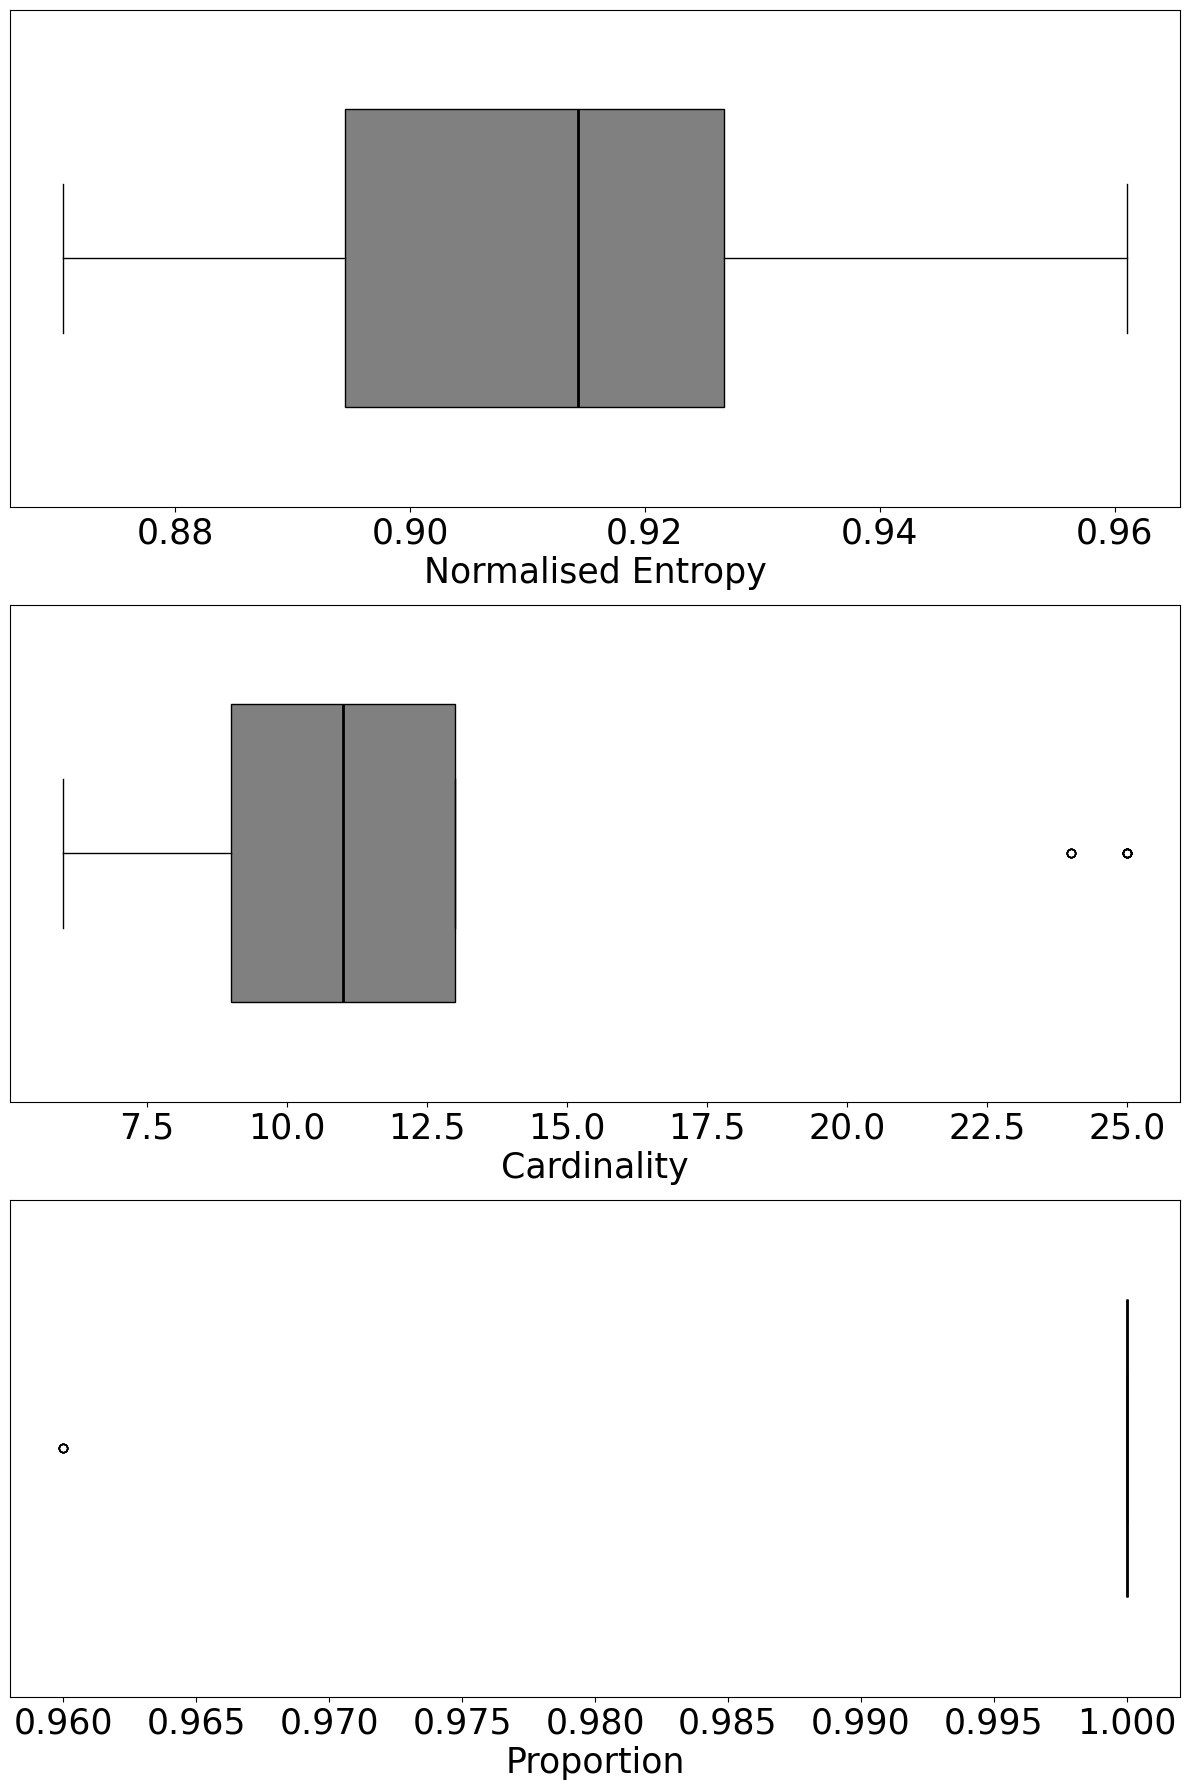

In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD RESULTS
# ============================================================

with open("/content/drive/MyDrive/multi_class/multiclass_results_dataset_188.pkl", "rb") as f:
    results = pickle.load(f)


# ============================================================
# COMBINE SUMMARIES FROM ALL CV REPETITIONS
# ============================================================

summary_df = pd.concat(
    results["summaries"],
    ignore_index=True
)



fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 18)
)

# Entropy
bp = axes[0].boxplot(
    summary_df["normalized_entropy"].dropna(),
    vert=False,
    widths=0.6,
    patch_artist=True
)

for box in bp["boxes"]:
    box.set_facecolor("gray")
    box.set_edgecolor("black")

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

axes[0].set_xlabel("Normalised Entropy", fontsize=25)
axes[0].set_yticks([])
axes[0].tick_params(axis="x", labelsize=25)


# Cardinality
bp = axes[1].boxplot(
    summary_df["cardinality"].dropna(),
    vert=False,
    widths=0.6,
    patch_artist=True
)

for box in bp["boxes"]:
    box.set_facecolor("gray")
    box.set_edgecolor("black")

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

axes[1].set_xlabel("Cardinality", fontsize=25)
axes[1].set_yticks([])
axes[1].tick_params(axis="x", labelsize=25)


# Proportion
bp = axes[2].boxplot(
    summary_df["proportion"].dropna(),
    vert=False,
    widths=0.6,
    patch_artist=True
)

for box in bp["boxes"]:
    box.set_facecolor("gray")
    box.set_edgecolor("black")
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

axes[2].set_xlabel("Proportion", fontsize=25)
axes[2].set_yticks([])
axes[2].tick_params(axis="x", labelsize=25)


plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/multi_class/multiclass_real_details_188.pdf",
    bbox_inches="tight",
    pad_inches=0.3
)

plt.show()